# Enzyme design case study on chorismate mutase

> Reference: Russ et al., Science, 2020 (https://www.science.org/doi/10.1126/science.aba3304)

> Note that Multiple sequence alignment in this paper starts based on a profile from 3D structure alignment, leading to model that also contains 2 insertions relative to EcCM (96 positions in model). We focus sequences on EcCM positions.

In [1]:
import pandas as pd
import torch
from scipy.stats import spearmanr
from evedesign.system import System, Protein, SystemInstance, EntityInstance
from evedesign.tools.mmseqs2 import add_sequences_mmseqs2, filter_entity_sequences_mmseqs
from evedesign.models.evmutation2 import EVmutation2
from evedesign.analyzers.sequence_space import SequenceSpacePCA
from evedesign.constants import GAP
from evedesign.codons.dnachisel import DNAChiselCodonOptimizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

/Users/thomashopf/mambaforge/envs/modal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data 

In [2]:
# from Russ et al. supplement
data_designs = pd.read_csv("russ_data_designs.csv")
data_natural = pd.read_csv("russ_data_natural.csv")

# For simplicity, we focus the model on the 94 positions in EcCM
keep_pos = [
    i for i, aa in enumerate(data_natural["Sequence"].iloc[0]) if aa != GAP
]

In [3]:
data_designs.head()

,No.,T,reg. value,Sequence,ID to EcCM,top ID,EDCA (rel. to EcCM),norm r.e.
0,1131,0.33,0.01,--TDNPLLALRERISALDLKLLALLAERRALALEVARTKLASHRPI...,0.78,0.82,-16.37,0.85
1,1132,0.33,0.01,LLVGLFFSTTALAAAIPSEDVASLINQRLSYMKDVAGYKANNHLAI...,0.14,0.84,-0.39,0.04
2,1133,0.33,0.01,PEDCEGLADIRRGIDALDREIVQILGRRLGYVKAASQFKPSEQ--I...,0.20,0.73,-3.03,-0.02
3,1134,0.33,0.01,PAAREELLELRGSIDNIDAALVHLLAERFKCTQRVGRLKARHGLPP...,0.30,0.81,-9.73,-0.11
4,1135,0.33,0.01,----KKLEEYRKEIDEIDKEIIKLFEKRMDVVLKVIEYKKKNNMPI...,0.18,0.65,0.70,0.88


In [4]:
data_natural.head()

,No.,Species,Sequence,ID to EcCM,top ID,EDCA (rel. to EcCM),norm r.e.
0,1,Escherichia coli ...,-TSENPLLALREKISALDEKLLALLAERRELAVEVGKAKLLSHRPV...,1.00,0.93,0.00,1.00
1,2,Thermus thermophilus HB8 ...,---DERIQALRKEVDRVNREILRLLSERGRLVQEIGRLQTELGLPH...,0.26,0.89,28.62,-0.06
2,3,Pseudomonas aeruginosa UCBPP-PA14 ...,PEDCTGLADIREAIDQIDLDIVQALGRRMDYVKAASRFKANEA-AI...,0.20,0.71,-4.19,0.04
3,4,Enterobacter cloacae subsp. dissolvens SDM ...,-TPENPLLDLRVKISALDEKLLALLAERRALAIEVGKAKLDSHRPV...,0.93,0.93,8.57,0.65
4,5,Thermus aquaticus Y51MC23 ...,---DERIQALRREVDRVNRELLRLLSERGRLVQEIGRIQTELGLPH...,0.28,0.89,18.42,-0.08


## Set up System and add sequences

In [5]:
# define single-protein system
system = System([
    Protein(
        id="EcCM", rep="TSENPLLALREKISALDEKLLALLAERRELAVEVGKAKLLSHRPVRDIDRERDLLERLITLGKAHHLDAHYITRLFQLIIEDSVLTQQALLQQH", first_index=2
    ),
])

In [6]:
# retrieve and add evolutionary sequences to system
system = add_sequences_mmseqs2(
    system, use_pairing=False, use_env=True
)

# perform some extra redundancy reduction on sequences which ColabFold server does not handle with env=True
system[0].sequences = filter_entity_sequences_mmseqs(
    system[0], max_seq_id=0.90
)

In [7]:
# build model on system
evm2 = EVmutation2(
    encoder_num_samples=4,
    decoder_num_full_samples=8,
    decoder_num_mutant_samples=8,
    device=DEVICE,
    fix_full_decoding_order=True
).build(system)

## Predict experimental data

> Natural sequences (Table S1) and designed sequences (Table S2)

> Need to remap sequences in table to target sequence by excluding gap positions in target in table

In [8]:
# instances for natural sequences
instances_natural =  [
    SystemInstance([
        EntityInstance(
            rep="".join([aa for i, aa in enumerate(s) if i in keep_pos])
        )
    ]) for s in data_natural["Sequence"]
]

# instances for designs, focus by WT sequence from natural sequences
instances_designs =  [
    SystemInstance([
        EntityInstance(
            rep="".join([aa for i, aa in enumerate(s) if i in keep_pos])
        )
    ]) for s in data_designs["Sequence"]
]

In [9]:
# score natural sequences (first instance is WT, use for normalization)
scores_natural = evm2.score(instances_natural)
scores_natural -= scores_natural[0]

In [10]:
# check correlation against data
spearmanr(scores_natural, data_natural["norm r.e."])

SignificanceResult(statistic=np.float64(0.45847223973232976), pvalue=np.float64(8.195943805873881e-60))

In [11]:
# score designs, normalize to WT
scores_designs = evm2.score(instances_designs) - scores_natural[0]

In [12]:
# check correlation against data
spearmanr(scores_designs, data_designs["norm r.e."])

SignificanceResult(statistic=np.float64(0.4373213867200264), pvalue=np.float64(1.4780021643035507e-76))

## Generate new sequences

In [13]:
new_designs = evm2.generate(
    num_designs=64, temperature=1.0
)

new_designs

[SystemInstance([EntityInstance(rep=TSENELNQAREKINVLDQKMMRLLSERMRIAEEVGKYKQATEPPVLQPER..., models=None)] id=None score=-129.7570343017578),
 SystemInstance([EntityInstance(rep=TGEDAMDALRERIDSVDEEILNTLERRMKLVGIIGLIKLENNVAIVDQER..., models=None)] id=None score=-118.34941101074219),
 SystemInstance([EntityInstance(rep=TANQPLEELREEIDIIDTDLLNLLAERMHVAHGIGKYKRAMQKPIRDSQR..., models=None)] id=None score=-110.49494934082031),
 SystemInstance([EntityInstance(rep=SASNDLGTLRQEIDRLDEDLLGLLAERTELAAEVVAYKRRRNKPVRQRDR..., models=None)] id=None score=-112.50563049316406),
 SystemInstance([EntityInstance(rep=TSKNELMLLRDQIDSIDDQLLAALAQRRELVDKIAQAQLENDIPPVQHDR..., models=None)] id=None score=-113.52548217773438),
 SystemInstance([EntityInstance(rep=TSGTELVEFRRRIDMLDEDLLTLLKRRMQLVQQIARRKNESNRTIFQPDR..., models=None)] id=None score=-118.93820190429688),
 SystemInstance([EntityInstance(rep=TTPDSLTDLRKKILAADAGLITRLIKRFRMARAILRLKMESGMPVEQLQR..., models=None)] id=None score=-150.7958526611328),
 SystemInstance

## Create nucleotide sequences from designs

In [14]:
codon_opt = DNAChiselCodonOptimizer(
    method="use_best_codon",
    codon_usage_table="h_sapiens",
    avoid_sites=["BsaI"],
    gc_min=0.33,
    gc_max=0.66,
    gc_window=50,
    cpu=1,
)

In [15]:
# could also optimize relative to a reference instance for making DNA background more constant but not doing here
dna_seqs = codon_opt.optimize(
    system=system,
    instances=new_designs,
    entity=0,
    upstream_dna="CATGCGCCGGTGTTTTAAATATG",
    downstream_dna="TAATCCTAGTCTTCTCGCCA",
)

In [16]:
# and here are final DNA sequences, note they do not include the upstream/downstream sequences which need to be added by user
dna_seqs

,rep,dna,score
0,TSENELNQAREKINVLDQKMMRLLSERMRIAEEVGKYKQATEPPVL...,ACCAGCGAGAACGAGCTGAACCAGGCCCGGGAGAAGATCAACGTGC...,-0.600866
1,TGEDAMDALRERIDSVDEEILNTLERRMKLVGIIGLIKLENNVAIV...,ACCGGCGAGGACGCCATGGATGCCCTGAGGGAGCGGATCGACAGCG...,-0.515503
2,TANQPLEELREEIDIIDTDLLNLLAERMHVAHGIGKYKRAMQKPIR...,ACCGCCAACCAGCCCCTGGAGGAGCTGCGGGAGGAGATCGACATCA...,-0.248790
3,SASNDLGTLRQEIDRLDEDLLGLLAERTELAAEVVAYKRRRNKPVR...,AGCGCCAGCAACGACCTGGGCACCCTGAGACAGGAGATCGACAGAC...,-1.247962
4,TSKNELMLLRDQIDSIDDQLLAALAQRRELVDKIAQAQLENDIPPV...,ACCAGCAAGAACGAGCTGATGCTGCTGAGGGACCAGATCGACAGCA...,-1.481063
...,...,...,...
59,TSPQDLAALRARISHLDARLLALLGRREDAVCRIAQAKNRNNLPVR...,ACCAGCCCCCAGGACCTGGCCGCCCTGAGGGCCAGAATCAGCCACC...,-1.198783
60,TSPSPLKILRGRIDDLDGNLLALLSQRRRVAAAIGKSKKQNNTPIR...,ACAAGCCCTAGCCCCCTGAAGATCCTGAGGGGCAGAATCGACGACC...,-1.419095
61,TTEDPLDLLRAKIDQVDQEILAILNRRLELAAQIADAKAEHHIPIR...,ACCACCGAGGACCCCCTGGATCTGCTGAGGGCCAAGATCGACCAGG...,-1.116990
62,SSQNDLGELRDRISQLDRELLTLLAERRRLSMSIGKVKKENQKPFR...,AGCAGCCAGAACGACCTGGGCGAGCTGAGGGACAGAATCTCTCAGC...,-1.056705


## Visualize new designs in context of sequence space

In [17]:
pca = SequenceSpacePCA(
     include_system_sequences=True
)

pca_res = pca.distances_and_projection(
    system, new_designs
)[1]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<Axes: >

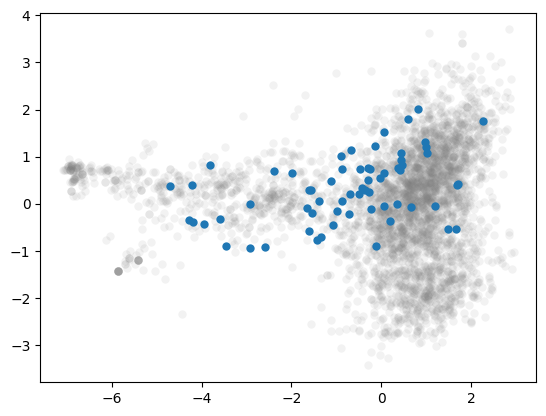

In [18]:
# not a dependency of evedesign, needs to be installed separately
import seaborn as sns

# natural sequences
sns.scatterplot(
    x=pca_res[:-len(new_designs), 0], y=pca_res[:-len(new_designs), 1], color="grey", alpha=0.1, lw=0
)

# designs
sns.scatterplot(
    x=pca_res[-len(new_designs):, 0], y=pca_res[-len(new_designs):, 1], lw=0
)